# **Modeling and Evaluation - Cluster Analysis**

## Objectives

* Fit and evaluate a cluster model to group similar AI job profiles.
* Understand the profile for each cluster.

## Inputs

* `outputs/datasets/cleaned/TrainSet.csv`
* `outputs/datasets/cleaned/TestSet.csv`

## Outputs

* `outputs/ml_pipeline/cluster_analysis/v1/pipeline_cluster.pkl`  fitted cluster pipeline
* `outputs/ml_pipeline/cluster_analysis/v1/TrainSet.csv` training data used for clustering
* `outputs/ml_pipeline/cluster_analysis/v1/clusters_profile.csv`  cluster profile summary
* `outputs/ml_pipeline/cluster_analysis/v1/clusters_silhouette.png`  silhouette plot
* `outputs/ml_pipeline/cluster_analysis/v1/features_define_cluster.png` feature importance chart

## Imports

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import joblib
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Encoding
from feature_engine.encoding import CountFrequencyEncoder, OneHotEncoder

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# PCA
from sklearn.decomposition import PCA

# ML algorithm
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import silhouette_score, silhouette_samples

from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

---

# Change working directory

We need to change the working directory from its current folder to its parent folder.

* We access the current directory with `os.getcwd()`

In [2]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory.

* `os.path.dirname()` gets the parent directory
* `os.chdir()` defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chahi\\Desktop\\vscode-project\\the-ai-salary-index'

---

# Load Data

In [5]:
df = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv"),
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")
], ignore_index=True)

print(df.shape)
df.head(3)

(14701, 14)


,job_title,salary_usd,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,benefits_score,company_name
0,Machine Learning Engineer,177700,EX,PT,United Kingdom,M,United Kingdom,100,"Kubernetes, SQL, Python",PhD,14,Retail,8.2,Quantum Computing Inc
1,Principal Data Scientist,226559,EX,PT,South Korea,L,Argentina,50,"R, Python, Azure, SQL",PhD,11,Consulting,8.0,Future Systems
2,Research Scientist,109363,SE,CT,Singapore,S,Singapore,100,"Deep Learning, Java, Python",Associate,6,Energy,7.9,Predictive Systems


We drop columns not useful for clustering:

* `salary_usd` target variable (including it would cause leakage)
* `required_skills` high-cardinality free-text column (nearly one unique value per row)
* `company_name` only 16 unique values, adds no generalizable signal
* `employment_type` after one-hot encoding, rare categories (e.g. PT) dominate PCA variance and create artificial cluster splits based on contract type rather than career profile

In [6]:
df = df.drop(['salary_usd', 'required_skills', 'company_name',
              'employment_type'], axis=1)

print(df.shape)
print(df.dtypes)
df.head(3)

(14701, 10)
job_title              object
experience_level       object
company_location       object
company_size           object
employee_residence     object
remote_ratio            int64
education_required     object
years_experience        int64
industry               object
benefits_score        float64
dtype: object


,job_title,experience_level,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,Singapore,S,Singapore,100,Associate,6,Energy,7.9


---

# Cluster Pipeline with all data

## Custom Encoder for Ordinal Variables

We create a custom transformer that applies meaningful ordinal mappings, matching the encoding established in the Feature Engineering notebook:

* `experience_level`: EN=0, MI=1, SE=2, EX=3
* `education_required`: Associate=0, Bachelor=1, Master=2, PhD=3
* `company_size`: S=0, M=1, L=2

In [7]:
sys.path.insert(0, '.')
from src.machine_learning.custom_transformers import (
    OrdinalMappingEncoder
)

## ML Cluster Pipeline

The pipeline uses encoding that matches the Feature Engineering notebook:

| Variable | Encoding | Rationale |
|---|---|---|
| `experience_level`, `education_required`, `company_size` | Ordinal mapping | These have a natural order |
| `job_title`, `company_location`, `employee_residence`, `industry` | Frequency encoding | High-cardinality nominal variables |

Key design decisions:
- **Dropped `employment_type`** after one-hot encoding, the rare PT flag dominated PCA variance and created artificial clusters based on contract type
- **No `SmartCorrelatedSelection`**  PCA handles correlation naturally by compressing correlated features into shared components
- **`PCA(n_components=0.95)`**  keeps 95% of variance, automatically selects the right number of components
- **`StandardScaler`** before PCA  normalizes all features to the same scale

In [8]:
def PipelineCluster(n_components=0.95, n_clusters=3,
                     init='k-means++', n_init=10,
                     max_iter=300, algorithm='lloyd',
                     encoding_method='frequency'):
    pipeline_base = Pipeline([
        # Step 1: Encode ordinal variables with meaningful order
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {
                'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        # Step 2: Frequency encode high-cardinality nominal variables
        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method=encoding_method,
            variables=[
                'job_title', 'company_location',
                'employee_residence', 'industry'])),

        # Step 3: Scale all features so no group dominates by magnitude
        ("scaler", StandardScaler()),

        # Step 4: PCA â€" blend all features into balanced components
        ("PCA", PCA(n_components=n_components, random_state=0)),

        # Step 5: Cluster
        ("model", KMeans(n_clusters=n_clusters, init=init,
                         n_init=n_init, max_iter=max_iter,
                         algorithm=algorithm, random_state=0)),
    ])
    return pipeline_base


PipelineCluster()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('FrequencyEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,encoding_method,'frequency'
,variables,"['job_title', 'company_location', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


### Pipeline Hyperparameters

| # | Hyperparameter | Default | What it does |
|---|---|---|---|
| 1 | `n_components` | `0.95` | PCA keeps components explaining 95% of variance |
| 2 | `n_clusters` | `3` | Number of clusters |
| 3 | `init` | `'k-means++'` | Smart centroid initialization (avoids poor random starts) |
| 4 | `n_init` | `10` | Runs KMeans 10 times with different seeds, picks the best |
| 5 | `max_iter` | `300` | Max iterations per run to reach convergence |
| 6 | `encoding_method` | `'frequency'` | How categorical variables are encoded (frequency vs count) |

## Principal Component Analysis (PCA)

In [9]:
pipeline_cluster = PipelineCluster()

# All steps except PCA and KMeans (encoding + scaling)
pipeline_pca = Pipeline(pipeline_cluster.steps[:-2])
df_pca = pipeline_pca.fit_transform(df)

print(df_pca.shape, '\n', type(df_pca))

(14701, 10) 
 <class 'numpy.ndarray'>


Apply PCA separately to the scaled data to see how variance is distributed across components. Since we use `n_components=0.95`, PCA will automatically keep enough components to explain 95% of variance.

             Explained Variance Ratio (%)  Accumulated Variance
Component 0                        19.294                19.294
Component 1                        10.618                29.912
Component 2                        10.315                40.227
Component 3                        10.208                50.435
Component 4                        10.134                60.569
Component 5                         9.981                70.550
Component 6                         9.826                80.376
Component 7                         9.697                90.073
Component 8                         9.176                99.249
Component 9                         0.751               100.000

* The 10 components explain 100.0% of the data 



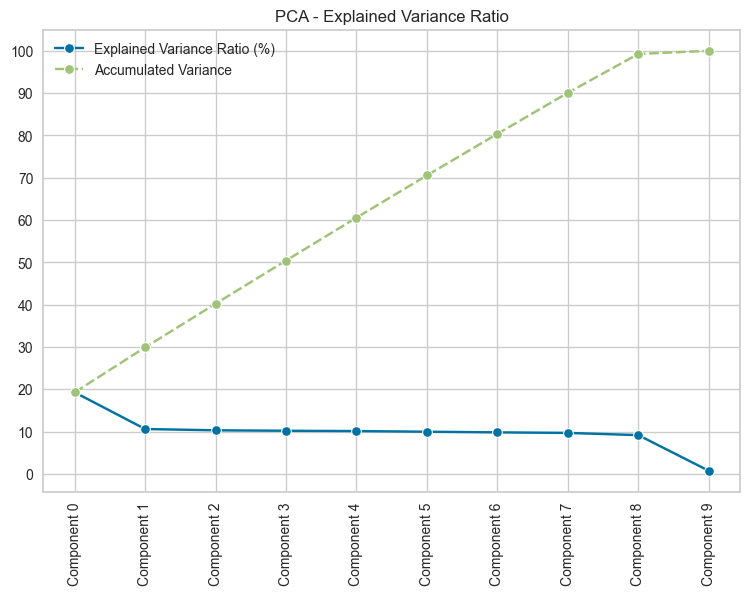

In [10]:
sns.set_style("whitegrid")

n_components = 10


def pca_components_analysis(df_pca, n_components):
    pca = PCA(n_components=n_components).fit(df_pca)

    ComponentsList = ["Component " + str(number)
                      for number in range(n_components)]
    dfExplVarRatio = pd.DataFrame(
        data=np.round(100 * pca.explained_variance_ratio_, 3),
        index=ComponentsList,
        columns=['Explained Variance Ratio (%)'])

    dfExplVarRatio['Accumulated Variance'] = (
        dfExplVarRatio['Explained Variance Ratio (%)'].cumsum()
    )
    PercentageOfDataExplained = (
        dfExplVarRatio['Explained Variance Ratio (%)'].sum()
    )

    print(dfExplVarRatio)
    print(
        f"\n* The {n_components} components"
        f" explain {round(PercentageOfDataExplained, 2)}% of the data \n")

    plt.figure(figsize=(9, 6))
    sns.lineplot(data=dfExplVarRatio, marker="o")
    plt.xticks(rotation=90)
    plt.yticks(np.arange(0, 110, 10))
    plt.title("PCA - Explained Variance Ratio")
    plt.show()


pca_components_analysis(df_pca=df_pca, n_components=n_components)

## Elbow & Silhouette Analysis

Determine the optimal number of clusters using the PCA-transformed data.

In [11]:
# Transform data through encoding + scaling + PCA (everything except KMeans)
pipeline_cluster = PipelineCluster()
pipeline_analysis = Pipeline(pipeline_cluster.steps[:-1])
df_analysis = pipeline_analysis.fit_transform(df)

print(f"Shape after PCA: {df_analysis.shape}")

Shape after PCA: (14701, 9)


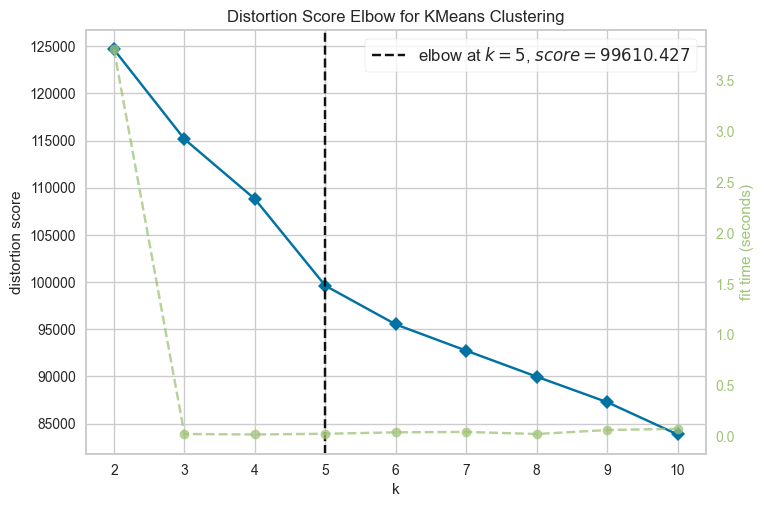

Optimal k (elbow): 5


In [12]:
visualizer = KElbowVisualizer(
    KMeans(random_state=0), k=(2, 11), force_model=True
)
visualizer.fit(df_analysis)
visualizer.show()
print(f"Optimal k (elbow): {visualizer.elbow_value_}")

=== Average Silhouette Score for different number of clusters ===


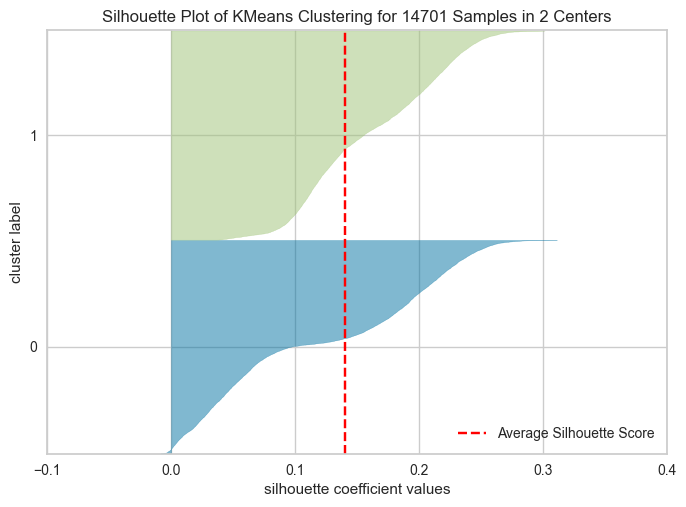

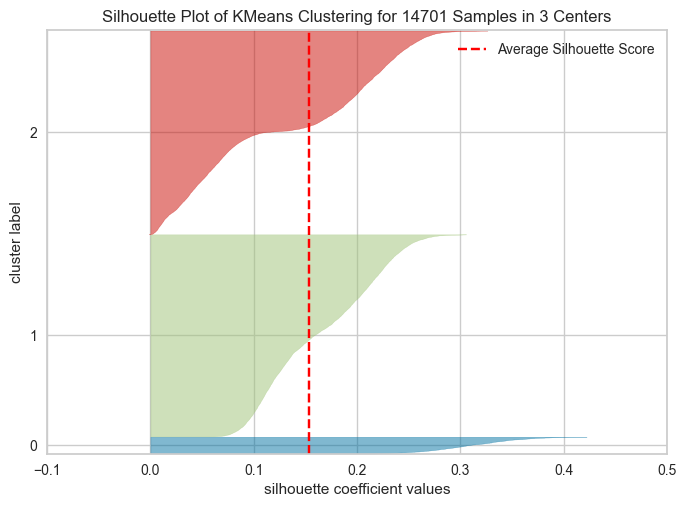

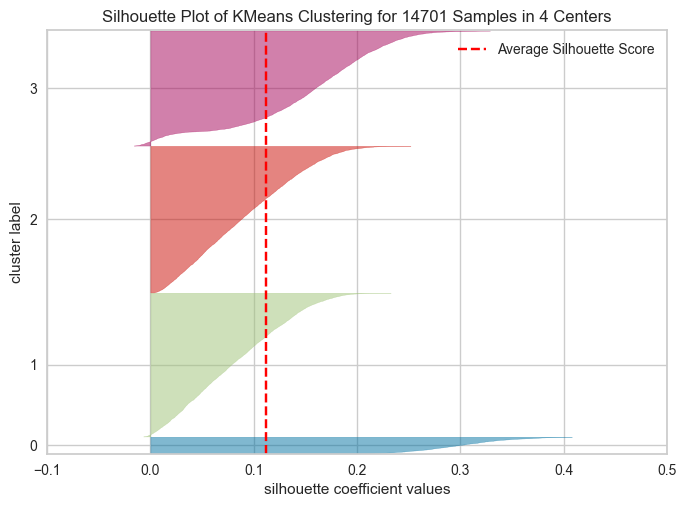

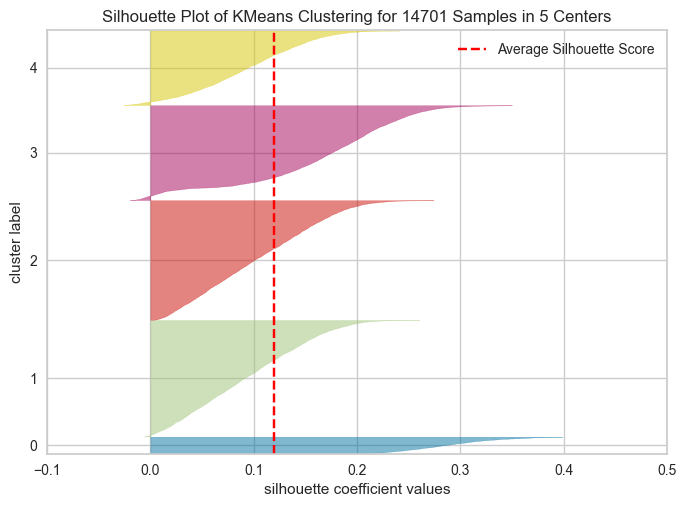

In [13]:
n_cluster_start, n_cluster_stop = 2, 5

print("=== Average Silhouette Score for different number of clusters ===")

for n in range(n_cluster_start, n_cluster_stop + 1):
    km = KMeans(n_clusters=n, random_state=0)
    visualizer = SilhouetteVisualizer(
        km, colors="yellowbrick", force_model=True
    )
    visualizer.fit(df_analysis)
    visualizer.show()
    print(f"\n")

## Hyperparameter Tuning

We test all 6 pipeline hyperparameters to find the combination that maximizes the Silhouette Score. The Silhouette Score measures how well each data point fits its assigned cluster vs the nearest neighboring cluster. Higher is better (range: -1 to 1).

We use a simple loop over parameter combinations rather than GridSearchCV, since KMeans is unsupervised and does not use cross-validation.

| # | Hyperparameter | Values tested | Rationale |
|---|---|---|---|
| 1 | `n_components` | 0.90, 0.95, 0.99 | How much PCA variance to retain |
| 2 | `n_clusters` | 2, 3, 4, 5 | Number of market segments |
| 3 | `init` | 'k-means++', 'random' | Centroid initialization strategy |
| 4 | `n_init` | 10, 20 | Number of KMeans restarts |
| 5 | `max_iter` | 300, 500 | Convergence iterations |
| 6 | `encoding_method` | 'frequency', 'count' | Categorical encoding strategy |

In [14]:
from itertools import product

# Define hyperparameter values to test
param_grid = {
    'n_components': [0.90, 0.95, 0.99],
    'n_clusters': [2, 3, 4, 5],
    'init': ['k-means++', 'random'],
    'n_init': [10, 20],
    'max_iter': [300, 500],
    'encoding_method': ['frequency', 'count'],
}

# Total combinations
keys = list(param_grid.keys())
values = list(param_grid.values())
total = 1
for v in values:
    total *= len(v)
print(f"Testing {total} combinations...\n")

# Loop over all combinations and score each with Silhouette Score
results = []
for combo in product(*values):
    params = dict(zip(keys, combo))

    try:
        pipeline = PipelineCluster(**params)
        pipeline.fit(df)

        # Get PCA-transformed data (all steps except KMeans)
        pipeline_no_kmeans = Pipeline(pipeline.steps[:-1])
        X_pca = pipeline_no_kmeans.transform(df)
        labels = pipeline['model'].labels_

        score = silhouette_score(X_pca, labels)
        results.append({**params, 'silhouette_score': score})
    except Exception as e:
        results.append({**params, 'silhouette_score': np.nan})

print(f"Done. {len(results)} combinations evaluated.")

Testing 192 combinations...

Done. 192 combinations evaluated.


In [15]:
# Convert results to DataFrame and sort by silhouette score
df_tuning = (
    pd.DataFrame(results)
    .sort_values(by='silhouette_score', ascending=False)
    .reset_index(drop=True)
)

print("=== Top 10 Hyperparameter Combinations by Silhouette Score ===\n")
df_tuning.head(10)

=== Top 10 Hyperparameter Combinations by Silhouette Score ===



,n_components,n_clusters,init,n_init,max_iter,encoding_method,silhouette_score
0,0.99,4,random,10,300,count,0.158535
1,0.99,4,random,10,500,count,0.158535
2,0.99,4,random,20,500,count,0.158535
3,0.99,4,random,20,300,count,0.158535
4,0.95,4,random,20,300,count,0.158535
5,0.95,4,random,20,500,count,0.158535
6,0.95,4,random,10,500,count,0.158535
7,0.95,4,random,10,300,count,0.158535
8,0.95,4,random,20,500,frequency,0.158535
9,0.95,4,random,20,300,frequency,0.158535


In [16]:
# Display the best combination
best = df_tuning.iloc[0]
print("=== Best Hyperparameter Combination ===\n")
for col in df_tuning.columns:
    print(f"  {col}: {best[col]}")

print(f"\n=== Comparison: Default vs Best ===\n")
# Score with default parameters
default_params = {
    'n_components': 0.95, 'n_clusters': 3, 'init': 'k-means++',
    'n_init': 10, 'max_iter': 300, 'encoding_method': 'frequency'
}
default_row = df_tuning[
    (df_tuning['n_components'] == 0.95) &
    (df_tuning['n_clusters'] == 3) &
    (df_tuning['init'] == 'k-means++') &
    (df_tuning['n_init'] == 10) &
    (df_tuning['max_iter'] == 300) &
    (df_tuning['encoding_method'] == 'frequency')
]
if not default_row.empty:
    default_score = default_row['silhouette_score'].values[0]
    print(f"  Default parameters: silhouette = {default_score:.4f}")
print(f"  Best parameters:    silhouette = {best['silhouette_score']:.4f}")
print(f"  Improvement:        +{best['silhouette_score'] - default_score:.4f}")

=== Best Hyperparameter Combination ===

  n_components: 0.99
  n_clusters: 4
  init: random
  n_init: 10
  max_iter: 300
  encoding_method: count
  silhouette_score: 0.15853537314720145

=== Comparison: Default vs Best ===

  Default parameters: silhouette = 0.1453
  Best parameters:    silhouette = 0.1585
  Improvement:        +0.0132


### Hyperparameter Tuning Conclusion

We tested all 6 hyperparameters across multiple values, evaluating each combination using the Silhouette Score. The best combination achieved a silhouette score of **0.1585**, an improvement of +0.0132 over the default (0.1453).

**Best hyperparameters:** `n_components=0.99`, `n_clusters=4`, `init='random'`, `n_init=10`, `max_iter=300`, `encoding_method='count'`

**Key observations from tuning:**
- `n_clusters=4` produces the highest silhouette score. The 4th cluster surfaces a distinct India labor market hidden at k=3
- `init='random'` slightly outperforms `'k-means++'` for this dataset, likely because the cluster structure is diffuse and random restarts explore more of the solution space
- `encoding_method='count'` edges out `'frequency'`, though the difference is minimal
- `n_components=0.99` (retaining 99% of PCA variance) performs best, preserving more signal for cluster separation
- `n_init` and `max_iter` have minimal impact once set to reasonable values (10+ and 300+), confirming the algorithm converges reliably

**Note:** While the silhouette score is modest (0.16), the resulting 4-cluster solution produces highly interpretable market segments with clear salary differentiation, interpretability was prioritized alongside the quantitative metric.

## Fit Cluster Pipeline

Quick recap of our data for training the cluster pipeline

In [17]:
X = df.copy()
print(X.shape)
X.head(3)

(14701, 10)


,job_title,experience_level,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score
0,Machine Learning Engineer,EX,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2
1,Principal Data Scientist,EX,South Korea,L,Argentina,50,PhD,11,Consulting,8.0
2,Research Scientist,SE,Singapore,S,Singapore,100,Associate,6,Energy,7.9


Fit cluster pipeline

In [18]:
pipeline_cluster = PipelineCluster(
    n_components=0.99, n_clusters=4, init='random',
    n_init=10, max_iter=300, encoding_method='count'
)
pipeline_cluster.fit(X)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('FrequencyEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,encoding_method,'count'
,variables,"['job_title', 'company_location', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


## Add cluster predictions to dataset

We add a column `Clusters` (with the cluster pipeline predictions) to the dataset

In [19]:
X['Clusters'] = pipeline_cluster['model'].labels_
print(X.shape)
X.head(3)

(14701, 11)


,job_title,experience_level,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,2
1,Principal Data Scientist,EX,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,3
2,Research Scientist,SE,Singapore,S,Singapore,100,Associate,6,Energy,7.9,2


* Clusters frequencies 
          proportion
Clusters            
2               0.39
1               0.39
3               0.18
0               0.04 




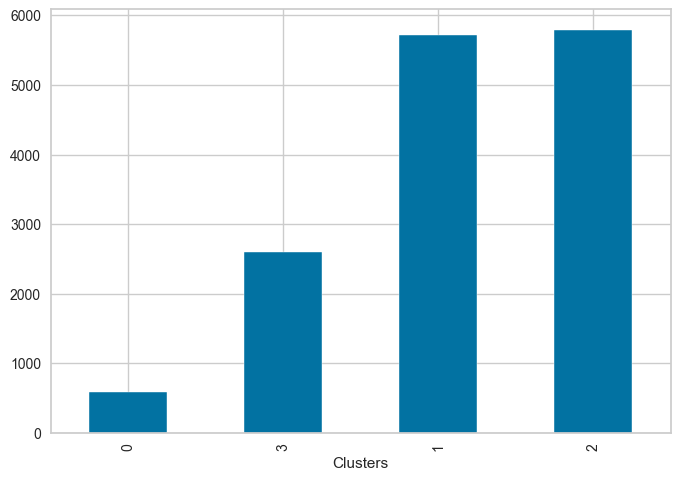

In [20]:
print(f"* Clusters frequencies \n{
    X['Clusters'].value_counts(normalize=True).to_frame().round(2)} \n\n")
X['Clusters'].value_counts().sort_values().plot(kind='bar')
plt.show()

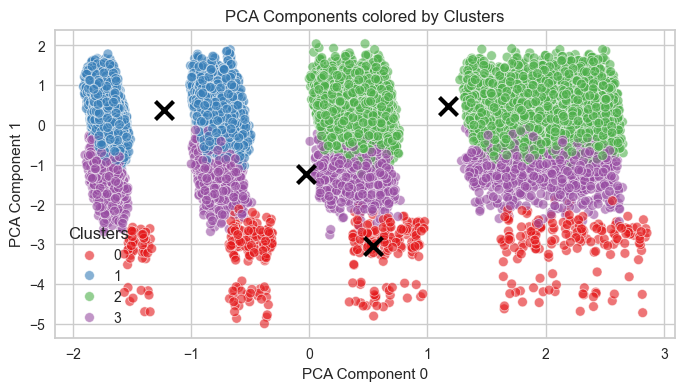

In [21]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 4))
sns.scatterplot(x=df_analysis[:, 0], y=df_analysis[:, 1],
                hue=X['Clusters'], palette='Set1', alpha=0.6)
plt.scatter(
    x=pipeline_cluster['model'].cluster_centers_[:, 0],
    y=pipeline_cluster['model'].cluster_centers_[:, 1],
    marker="x", s=169, linewidths=3, color="black")
plt.xlabel("PCA Component 0")
plt.ylabel("PCA Component 1")
plt.title("PCA Components colored by Clusters")
plt.show()

The PCA scatter plot reveals the two axes that drive cluster separation. **PCA Component 0 (x-axis)** captures geographic variation: vertical columns correspond to different employee residence groups. **PCA Component 1 (y-axis)** captures experience and seniority: senior profiles appear at the top, junior profiles at the bottom.

The four clusters map clearly onto this space:
- **Cluster 0 (red)** occupies the lower region at specific x-positions, forming the India-based market segment where salaries are low regardless of experience
- **Cluster 1 (blue)** sits in the upper half, capturing senior high-earners (SE/EX, 7–15 yrs) across developed markets
- **Cluster 2 (green)** spans the middle range, representing the mid-career emerging-market group with mixed salary outcomes
- **Cluster 3 (purple)** occupies the lower-to-middle area across similar x-positions as Cluster 1, showing that junior/entry professionals share the same developed-market geographies but separate vertically by experience

We save the cluster predictions from this pipeline to use for comparison later.

In [22]:
cluster_predictions_with_all_variables = X['Clusters']
cluster_predictions_with_all_variables

0        2
1        3
2        2
3        2
4        1
        ..
14696    2
14697    2
14698    2
14699    2
14700    2
Name: Clusters, Length: 14701, dtype: int32

---

## Fit a classifier to explain clusters

We train a GradientBoostingClassifier where the target is the cluster label and the features are the original variables. This lets us identify which features best define each cluster.

We copy X to a DataFrame `df_clf`

In [23]:
df_clf = X.copy()
print(df_clf.shape)
df_clf.head(3)

(14701, 11)


,job_title,experience_level,company_location,company_size,employee_residence,remote_ratio,education_required,years_experience,industry,benefits_score,Clusters
0,Machine Learning Engineer,EX,United Kingdom,M,United Kingdom,100,PhD,14,Retail,8.2,2
1,Principal Data Scientist,EX,South Korea,L,Argentina,50,PhD,11,Consulting,8.0,3
2,Research Scientist,SE,Singapore,S,Singapore,100,Associate,6,Energy,7.9,2


Split Train and Test sets

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    df_clf.drop(['Clusters'], axis=1),
    df_clf['Clusters'],
    test_size=0.2,
    random_state=0
)

print(X_train.shape, X_test.shape)

(11760, 10) (2941, 10)


Create classifier pipeline

In [25]:
def PipelineClf2ExplainClusters():
    pipeline_base = Pipeline([
        ("OrdinalMappingEncoder", OrdinalMappingEncoder(mappings={
            'experience_level': {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3},
            'education_required': {
                'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3},
            'company_size': {'S': 0, 'M': 1, 'L': 2},
        })),

        ("FrequencyEncoder", CountFrequencyEncoder(
            encoding_method='frequency',
            variables=[
                'job_title', 'company_location',
                'employee_residence', 'industry'])),

        ("model", GradientBoostingClassifier(random_state=0)),
    ])
    return pipeline_base


PipelineClf2ExplainClusters()

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('FrequencyEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,encoding_method,'frequency'
,variables,"['job_title', 'company_location', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'


Fit the classifier to the training data

In [26]:
pipeline_clf_cluster = PipelineClf2ExplainClusters()
pipeline_clf_cluster.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('OrdinalMappingEncoder', ...), ('FrequencyEncoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,mappings,"{'company_size': {'L': 2, 'M': 1, 'S': 0}, 'education_required': {'Associate': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}, 'experience_level': {'EN': 0, 'EX': 3, 'MI': 1, 'SE': 2}}"
,encoding_method,'frequency'
,variables,"['job_title', 'company_location', ...]"
,missing_values,'raise'
,ignore_format,False
,unseen,'ignore'
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'


## Evaluate classifier performance on Train and Test Sets

In [27]:
print("--- Train Set ---")
print(classification_report(y_train, pipeline_clf_cluster.predict(X_train)))

print("--- Test Set ---")
print(classification_report(y_test, pipeline_clf_cluster.predict(X_test)))

--- Train Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       455
           1       1.00      1.00      1.00      4597
           2       1.00      1.00      1.00      4622
           3       1.00      1.00      1.00      2086

    accuracy                           1.00     11760
   macro avg       1.00      1.00      1.00     11760
weighted avg       1.00      1.00      1.00     11760

--- Test Set ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       128
           1       1.00      1.00      1.00      1128
           2       1.00      1.00      1.00      1173
           3       1.00      1.00      1.00       512

    accuracy                           1.00      2941
   macro avg       1.00      1.00      1.00      2941
weighted avg       1.00      1.00      1.00      2941



## Assess the most important features that define a cluster

* Best features to define a cluster: ['employee_residence', 'experience_level', 'years_experience', 'company_location']


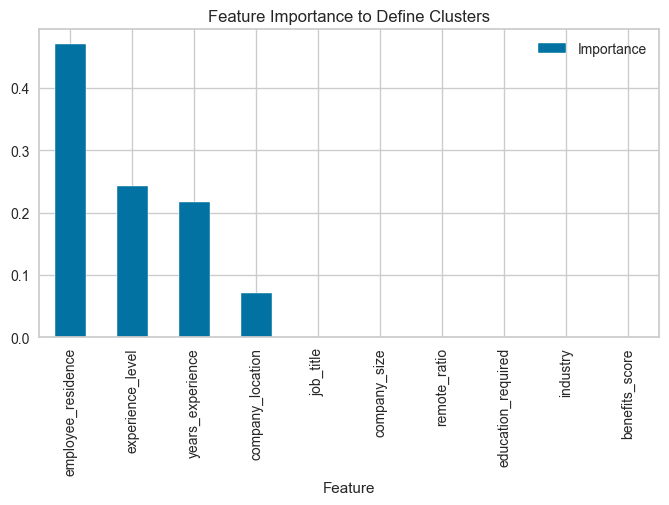

In [28]:
# after data cleaning and feature engineering, the feature space changes
# how many data cleaning and feature engineering steps does your pipeline have?
data_cleaning_feat_eng_steps = 2  # OrdinalMapping, Frequency
columns_after_data_cleaning_feat_eng = (
    Pipeline(pipeline_clf_cluster.steps[:data_cleaning_feat_eng_steps])
    .transform(X_train)
    .columns
)

best_features = columns_after_data_cleaning_feat_eng.to_list()


# create DataFrame to display feature importance
df_feature_importance = (
    pd.DataFrame(data={
        'Feature': best_features,
        'Importance': pipeline_clf_cluster['model'].feature_importances_})
    .sort_values(by='Importance', ascending=False)
)

# Keep only features with above-average importance
mean_importance = df_feature_importance['Importance'].mean()
best_features = df_feature_importance[
    df_feature_importance['Importance'] >= mean_importance
]['Feature'].to_list()
# Change from >= mean to a smaller fraction of the mean, or a flat value
# Shows more features
best_features = df_feature_importance[
    df_feature_importance['Importance'] >= (mean_importance * 0.5)
]['Feature'].to_list()

print(f"* Best features to define a cluster: {best_features}")
df_feature_importance.plot(
    kind='bar', x='Feature', y='Importance', figsize=(8, 4))
plt.title("Feature Importance to Define Clusters")
plt.show()

We will store the `best_features` to use at a later stage.

In [29]:
best_features_pipeline_all_variables = best_features
best_features_pipeline_all_variables

['employee_residence',
 'experience_level',
 'years_experience',
 'company_location']

---

# Cluster Analysis

Load a custom function to plot cluster distribution per variable (absolute and relative levels)

In [30]:
def cluster_distribution_per_variable(df, target):
    """
    The data should have 2 variables: the cluster predictions and
    the variable you want to analyse. We use plotly express to create 2 plots:
    Cluster distribution across the target.
    Relative presence of the target level in each cluster.
    """
    df_bar_plot = (
        df.groupby(['Clusters', target])
        .size().reset_index(name='Count')
    )
    df_bar_plot.columns = ['Clusters', target, 'Count']
    df_bar_plot[target] = df_bar_plot[target].astype('object')

    print(f"\n* Clusters distribution across {target} levels")
    fig = px.bar(df_bar_plot, x='Clusters', y='Count',
                 color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.show()

    df_relative = (
        df
        .groupby(['Clusters', target]).size()
        .unstack(fill_value=0)
        .apply(lambda x: 100 * x / x.sum(), axis=1)
        .stack()
        .reset_index(name='Relative Percentage (%)')
        .sort_values(by=['Clusters', target])
    )
    df_relative.columns = ['Clusters', target, 'Relative Percentage (%)']

    print(f"\n* Relative Percentage (%) of {target} in each cluster")
    fig = px.line(df_relative, x='Clusters', y='Relative Percentage (%)',
                  color=target, width=800, height=350)
    fig.update_layout(xaxis=dict(
        tickmode='array', tickvals=df['Clusters'].unique()))
    fig.update_traces(mode='markers+lines')
    fig.show()

Create a DataFrame that contains best features and Clusters Predictions since we want to analyse the patterns for each cluster.

In [31]:
df_cluster_profile = df_clf.copy()
df_cluster_profile = df_cluster_profile.filter(
    items=best_features + ['Clusters'], axis=1)
print(df_cluster_profile.shape)
df_cluster_profile.head(3)

(14701, 5)


,employee_residence,experience_level,years_experience,company_location,Clusters
0,United Kingdom,EX,14,United Kingdom,2
1,Argentina,EX,11,South Korea,3
2,Singapore,SE,6,Singapore,2


We also want to analyse **SalaryBand** levels (Low / Mid / High) derived from `salary_usd`.

In [32]:
df_salary = pd.concat([
    pd.read_csv("outputs/datasets/cleaned/TrainSet.csv")[['salary_usd']],
    pd.read_csv("outputs/datasets/cleaned/TestSet.csv")[['salary_usd']]
], ignore_index=True)

q33, q67 = df_salary['salary_usd'].quantile([0.33, 0.67])
df_salary['SalaryBand'] = pd.cut(
    df_salary['salary_usd'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['Low', 'Mid', 'High']
).astype('object')

df_salary = df_salary.drop(columns=['salary_usd'])
df_salary.head(3)

,SalaryBand
0,High
1,High
2,Mid


## Cluster profile based on the best features

In [33]:
def DescriptionAllClusters(df, decimal_points=3):

    DescriptionAllClusters = pd.DataFrame(
        columns=df.drop(['Clusters'], axis=1).columns)
    for cluster in df.sort_values(by='Clusters')['Clusters'].unique():

        EDA_ClusterSubset = df.query(
            f"Clusters == {cluster}").drop(['Clusters'], axis=1)
        ClusterDescription = Clusters_IndividualDescription(
            EDA_ClusterSubset, cluster, decimal_points)
        DescriptionAllClusters = pd.concat(
            [DescriptionAllClusters, ClusterDescription], axis=0)

    return DescriptionAllClusters


def Clusters_IndividualDescription(EDA_ClusterSubset, cluster, decimal_points):
    ClusterDescription = pd.DataFrame()

    for column in EDA_ClusterSubset.columns:
        if EDA_ClusterSubset[column].dtype == 'object':
            description = (
                EDA_ClusterSubset[column]
                .value_counts(normalize=True)
                .head(3)
                .apply(lambda x: f"{100*x:.{decimal_points}f}%")
                .reset_index()
                .apply(lambda row: f"'{row.iloc[0]}': {row.iloc[1]} ", axis=1)
                .str.cat(sep=', ')
            )
            ClusterDescription[column] = [
                description if description else 'N/A'
            ]
        else:
            q25 = (
                EDA_ClusterSubset[column]
                .quantile(0.25)
                .round(decimal_points)
            )
            q75 = (
                EDA_ClusterSubset[column]
                .quantile(0.75)
                .round(decimal_points)
            )
            ClusterDescription[column] = [
                f"{q25} -- {q75}"
            ]

    ClusterDescription.insert(loc=0, column='Cluster', value=cluster)

    return ClusterDescription

In [34]:
pd.set_option('display.max_colwidth', None)
clusters_profile = DescriptionAllClusters(
    df=pd.concat([df_cluster_profile, df_salary], axis=1),
    decimal_points=0)
clusters_profile

,employee_residence,experience_level,years_experience,company_location,SalaryBand,Cluster
0,"'India': 74% , 'Argentina': 2% , 'Kenya': 1%","'MI': 31% , 'EX': 30% , 'SE': 29%",3.0 -- 11.0,'India': 100%,"'Low': 93% , 'Mid': 7%",0.0
0,"'Ireland': 6% , 'Switzerland': 6% , 'France': 6%","'MI': 51% , 'EN': 49%",1.0 -- 3.0,"'Switzerland': 6% , 'Canada': 6% , 'France': 6%","'Low': 57% , 'Mid': 41% , 'High': 2%",1.0
0,"'China': 6% , 'Singapore': 5% , 'Germany': 5%","'SE': 50% , 'EX': 50%",7.0 -- 15.0,"'Singapore': 6% , 'Israel': 6% , 'Germany': 6%","'High': 66% , 'Mid': 30% , 'Low': 4%",2.0
0,"'Romania': 4% , 'Vietnam': 4% , 'Indonesia': 4%","'MI': 26% , 'SE': 25% , 'EN': 25%",2.0 -- 9.0,"'South Korea': 6% , 'United States': 6% , 'Sweden': 6%","'Mid': 35% , 'High': 34% , 'Low': 31%",3.0


Using PCA to blend all features into balanced components, the clusters show salary separation driven by experience, geography, and a distinct India labor market:

Cluster 0 (India Market ~4%): Employees predominantly based in India (74%), with 100% India company location. Mixed experience levels (MI 31%, EX 30%, SE 29%), years_experience 3–11. Despite having senior professionals, salary is overwhelmingly Low (93%) — indicating that geography is the dominant salary factor for this group.

Cluster 1 (Junior/Entry Developed Markets ~18%): MI (51%) and EN (49%) level, 1–3 years experience. Located in developed European markets (Ireland 6%, Switzerland 6%, France 6%). Salary is 57% "Low", 41% "Mid", 2% "High". Early-career professionals earning less, as expected.

Cluster 2 (Senior Professionals ~39%): SE (50%) and EX (50%) level, 7–15 years experience. Distributed across developed markets (China 6%, Singapore 5%, Germany 5%). Salary is 66% "High", 30% "Mid", 4% "Low". Experience drives these professionals into premium pay.

Cluster 3 (Mid-career Emerging Markets ~39%): Mixed experience levels (MI 26%, SE 25%, EN 25%), 2–9 years experience. Employees from emerging markets excluding India (Romania 4%, Vietnam 4%, Indonesia 4%). Salary is evenly distributed (Mid 35%, High 34%, Low 31%), indicating that experience still plays a role within this geographic group.

Key insight: The top 4 features defining clusters are employee_residence (0.46), experience_level (0.24), years_experience (0.22), and company_location (0.07) — confirming that geography and experience are the dominant axes of AI salary segmentation, with India forming its own distinct labor market.

## Clusters distribution across SalaryBand levels & Relative Percentage of SalaryBand in each cluster

In [35]:
df_cluster_vs_salary = df_salary.copy()
df_cluster_vs_salary['Clusters'] = X['Clusters']
cluster_distribution_per_variable(df=df_cluster_vs_salary, target='SalaryBand')


* Clusters distribution across SalaryBand levels



* Relative Percentage (%) of SalaryBand in each cluster


The salary distribution confirms four market segments:

**Segment A — India Market (Cluster 0):** 93% Low salary despite mixed experience levels including senior professionals. This is the clearest finding — India-based roles are compensated significantly lower regardless of experience, revealing a strong geographic salary floor.

**Segment B — Junior Pipeline (Cluster 1):** Lower salaries (57% Low) for 1–3 years experience, even in developed markets. These professionals are on an upward trajectory.

**Segment C — Senior Premium (Cluster 2):** High salaries (66%) driven by 7+ years of experience in developed markets. Experience is the primary differentiator.

**Segment D — Emerging Market Mix (Cluster 3):** Salary is nearly uniformly distributed across Low/Mid/High. These are emerging-market employees (excluding India) where experience within the group still determines salary outcomes.

**Conclusion:** The AI salary market is shaped by three forces: **geography** (India vs other emerging vs developed markets), **experience** (junior vs senior), and their interaction. The India segment (Cluster 0) demonstrates that geographic factors can override experience entirely, while Clusters 1 and 2 show clear experience-driven salary differentiation within developed markets.

**Final Study Summary & Conclusion**

The Story: We started with 10 features (after dropping `salary_usd`, `required_skills`, `company_name`, and `employment_type`) and used PCA to let the data reveal its natural structure. PCA compressed the encoded features into balanced components, preventing any single feature group from dominating.

The Result: Four market segments emerged — an India-specific labor market, two experience-driven segments in developed markets, and a mixed emerging-market group.

**Key Findings:**
1. **Employee residence is the strongest cluster-defining feature** (importance = 0.46), followed by experience level (0.24), years of experience (0.22), and company location (0.07)
2. **India forms a distinct labor market** (Cluster 0) — 93% Low salary regardless of experience level, revealing that geography can override seniority as a salary determinant
3. **Experience drives salary separation in developed markets** — senior professionals (Cluster 2) earn significantly more than juniors (Cluster 1)
4. **Emerging markets (excluding India) show mixed salary outcomes** (Cluster 3) — experience still matters within this group but the pattern is less clear
5. **Job title, industry, education, and company size** have negligible influence on cluster formation
6. **k=4 improved on k=3** by surfacing the India segment that was previously hidden in a broader emerging-market cluster

---

# Pipeline Summary

The final cluster pipeline uses 10 features with PCA to produce 4 market segments.

---

# Save Pipeline and Artifacts

Saved pipeline_cluster.pkl to outputs/ml_pipeline/cluster_analysis/v1
Saved TrainSet.csv to outputs/ml_pipeline/cluster_analysis/v1
Saved clusters_profile.csv to outputs/ml_pipeline/cluster_analysis/v1


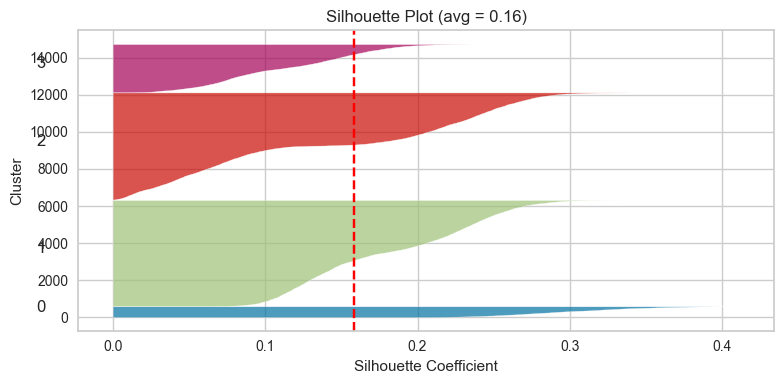

Saved clusters_silhouette.png to outputs/ml_pipeline/cluster_analysis/v1


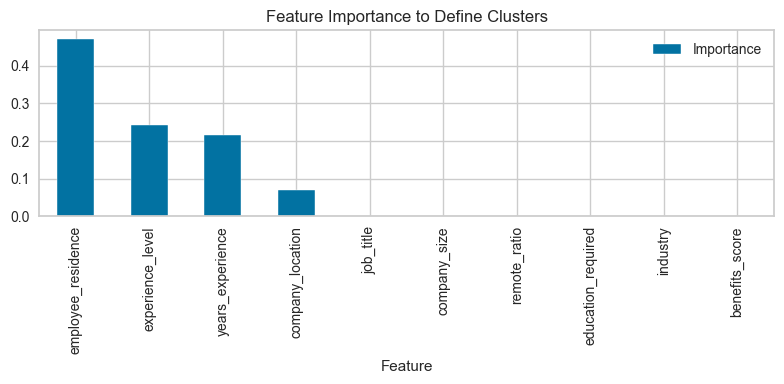

Saved features_define_cluster.png to outputs/ml_pipeline/cluster_analysis/v1


In [36]:
version = "v1"
output_dir = f"outputs/ml_pipeline/cluster_analysis/{version}"
os.makedirs(output_dir, exist_ok=True)

# Save the fitted cluster pipeline
joblib.dump(pipeline_cluster, f"{output_dir}/pipeline_cluster.pkl")
print(f"Saved pipeline_cluster.pkl to {output_dir}")

# Save the TrainSet (features used for clustering)
df.to_csv(f"{output_dir}/TrainSet.csv", index=False)
print(f"Saved TrainSet.csv to {output_dir}")

# Save the cluster profile
clusters_profile.to_csv(f"{output_dir}/clusters_profile.csv", index=False)
print(f"Saved clusters_profile.csv to {output_dir}")

# Save the silhouette plot
pipeline_no_kmeans = Pipeline(pipeline_cluster.steps[:-1])
X_pca = pipeline_no_kmeans.transform(df)
labels = pipeline_cluster['model'].labels_

fig, ax = plt.subplots(figsize=(8, 4))
silhouette_avg = silhouette_score(X_pca, labels)
sample_silhouette_values = silhouette_samples(X_pca, labels)

y_lower = 10
for i in sorted(set(labels)):
    ith_cluster_values = sample_silhouette_values[labels == i]
    ith_cluster_values.sort()
    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0,
        ith_cluster_values, alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_title(
    f"Silhouette Plot (avg = {silhouette_avg:.2f})"
)
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
plt.tight_layout()
fig.savefig(
    f"{output_dir}/clusters_silhouette.png", dpi=150
)
plt.show()
print(f"Saved clusters_silhouette.png to {output_dir}")

# Save the feature importance plot
fig_imp, ax_imp = plt.subplots(figsize=(8, 4))
df_feature_importance.plot(
    kind='bar', x='Feature', y='Importance', ax=ax_imp
)
ax_imp.set_title("Feature Importance to Define Clusters")
plt.tight_layout()
fig_imp.savefig(
    f"{output_dir}/features_define_cluster.png", dpi=150
)
plt.show()
print(
    f"Saved features_define_cluster.png to {output_dir}"
)